# Comparison with CryoSat-2/Sentinel-3/SMOS (CS3SMOS v300)

**Summary**: Preliminary comparison of IS2SMGPSIT-V1 with the retrospective AWI CryoSat-2/Sentinel-3/SMOS merged sea-ice-thickness product (CS3SMOS v300). CS3SMOS fields are centered 7-day analyses issued at daily target dates. We therefore compare each field with a centered 7-day mean of the daily IS2SMGPSIT-V1 output before constructing any monthly summaries.

The primary thickness comparison uses **effective grid-cell thickness**. CS3SMOS ice-only thickness is multiplied by its supplied sea-ice concentration before regridding to the 25 km IS2SMGPSIT-V1 grid. This matches the IS2SMGPSIT-V1 definition, in which open water contributes approximately zero thickness. Volume is computed independently on each native grid.

**Author**: Alek Petty  
**Version history**: Version 1 (08/2026)

Product documentation: [AWI CS3SMOS v300](https://spaces.awi.de/spaces/CS2SMOS/pages/297634429/CryoSat-2%2BSentinel-3%2BSMOS%2BMerged%2BSea%2BIce%2BThickness); method heritage: [Ricker et al. (2017)](https://doi.org/10.5194/tc-11-1607-2017).

In [1]:
# Import dependencies and locate the content directory robustly.
from pathlib import Path
import sys
import calendar

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.spatial import cKDTree


def _find_content_dir():
    candidates = [Path.cwd(), Path.cwd() / 'content', Path.cwd().parent / 'content']
    for candidate in candidates:
        if (candidate / 'utils').is_dir():
            return candidate.resolve()
    raise FileNotFoundError('Could not locate content/utils from the current working directory.')


CONTENT_DIR = _find_content_dir()
if str(CONTENT_DIR) not in sys.path:
    sys.path.insert(0, str(CONTENT_DIR))

from utils.read_data_utils import (
    read_is2smgpsitv1_zarr,
    is2smgpsit_domain_masks,
    area_weighted_spatial_mean,
)
from utils.plotting_utils import plot_is2_v4_vs_fused_three_panel

mpl.rcParams.update({
    'figure.dpi': 180,
    'font.family': 'sans-serif',
    'font.size': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
})
mpl.rcParams['font.sans-serif'] = ['Arial']

DATA_ROOT = CONTENT_DIR / 'data' / 'CS3SMOS_v300'
FIG_DIR = CONTENT_DIR / 'figs'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('Content directory:', CONTENT_DIR)
print('CS3SMOS directory:', DATA_ROOT)

Content directory: /Users/akpetty/GitHub/icesat2-book/content
CS3SMOS directory: /Users/akpetty/GitHub/icesat2-book/content/data/CS3SMOS_v300


## Load retrospective CS3SMOS v300 files

Only retrospective files (`processing_mode = r`) are used. Each file contains one analysis centered on a target date and based on a 7-day observation window. Files can be stored anywhere below `content/data/CS3SMOS_v300/`; the current `sample/` directory is discovered automatically.

In [2]:
cs3_files = sorted(DATA_ROOT.rglob('*_r_v300_01_l4sit.nc'))
if not cs3_files:
    raise FileNotFoundError(f'No retrospective v300 NetCDF files found below {DATA_ROOT}')

required_vars = [
    'sea_ice_thickness',
    'sea_ice_thickness_uncertainty',
    'sea_ice_concentration',
    'density_of_ocean',
    'status_flag',
    'quality_flag',
]

# Check identifying metadata file by file before combining.
window_bounds = []
for path in cs3_files:
    with xr.open_dataset(path) as _ds:
        if str(_ds.attrs.get('processing_mode', '')).lower() != 'r':
            raise ValueError(f'Non-retrospective file encountered: {path.name}')
        if str(_ds.attrs.get('product_version', '')).lstrip('v') != '300':
            raise ValueError(f'File is not product version 300: {path.name}')
        missing = [name for name in required_vars if name not in _ds]
        if missing:
            raise KeyError(f'{path.name} is missing variables: {missing}')
        if 'time_bnds' not in _ds.coords:
            raise KeyError(f'{path.name} is missing its 7-day time bounds')
        _bounds = pd.DatetimeIndex(_ds.time_bnds.values)
        if len(_bounds) != 2:
            raise ValueError(f'Unexpected time bounds in {path.name}: {_bounds}')
        window_bounds.append((_bounds[0], _bounds[1]))


def _keep_cs3_variables(ds):
    return ds[required_vars]


cs3 = xr.open_mfdataset(
    cs3_files,
    combine='nested',
    concat_dim='time',
    data_vars='minimal',
    coords='minimal',
    compat='override',
    preprocess=_keep_cs3_variables,
).sortby('time')

# V1 is timestamped at midnight; normalize the CS3SMOS 12:00 target times to dates.
target_dates = pd.DatetimeIndex(cs3.time.values).normalize()
if target_dates.duplicated().any():
    duplicates = target_dates[target_dates.duplicated()].strftime('%Y-%m-%d').tolist()
    raise ValueError(f'Duplicate CS3SMOS target dates: {duplicates}')
cs3 = cs3.assign_coords(time=target_dates.values)

window_days = np.array([
    (end - start) / np.timedelta64(1, 'D') for start, end in window_bounds
])
if not np.allclose(window_days, 7.0, atol=1e-6):
    raise ValueError(f'Unexpected CS3SMOS window duration(s): {np.unique(window_days)}')

print(f'Loaded {len(cs3_files)} retrospective CS3SMOS fields')
print('Target dates:', target_dates.min().date(), 'to', target_dates.max().date())
print('Grid:', cs3.sizes['yc'], 'x', cs3.sizes['xc'])

Loaded 2 retrospective CS3SMOS fields
Target dates: 2019-10-25 to 2020-03-15
Grid: 864 x 864


## Check temporal completeness

Northern Hemisphere CS3SMOS production nominally spans 15 October–15 April. Centered 7-day target dates therefore run approximately 18–31 October, every day in November–March, and 1–12 April. A month is only labeled as a monthly mean below when every expected target date is present.

In [3]:
def expected_cs3_targets(period):
    if period.month == 10:
        return 14  # target dates 18-31 October
    if period.month in [11, 12, 1, 2, 3]:
        return calendar.monthrange(period.year, period.month)[1]
    if period.month == 4:
        return 12  # target dates 1-12 April
    return 0


periods = target_dates.to_period('M')
coverage = pd.Series(1, index=periods).groupby(level=0).sum().rename('available_targets').to_frame()
coverage['expected_targets'] = [expected_cs3_targets(period) for period in coverage.index]
coverage['complete'] = coverage['available_targets'] == coverage['expected_targets']
coverage.index = coverage.index.astype(str)
display(coverage)

if not coverage['complete'].all():
    print('Incomplete months are retained as individual 7-day comparisons but are not treated as monthly means.')

,available_targets,expected_targets,complete
2019-10,1,14,False
2020-03,1,31,False


Incomplete months are retained as individual 7-day comparisons but are not treated as monthly means.


## Load IS2SMGPSIT-V1 and match the 7-day cadence

Negative GP thickness estimates are clipped to zero for area and volume calculations. Each CS3SMOS target date is paired with a centered 7-day mean of IS2SMGPSIT-V1. Summary statistics are reported for the Inner Arctic Ocean (NSIDC regions 1–5); the pan-Arctic volume mask excludes the Canadian Arctic Archipelago (region 12), consistent with notebook 11d. The maps retain each product's full available spatial coverage.

In [4]:
v1 = read_is2smgpsitv1_zarr(
    load_cache=True,
    persist=False,
    cache_dir=str(CONTENT_DIR / 'data' / 'cache'),
    cache_vars=['ice_thickness', 'grid_cell_area', 'region_mask'],
)

if target_dates.min() < pd.Timestamp(v1.time.min().values) or target_dates.max() > pd.Timestamp(v1.time.max().values):
    raise ValueError('One or more CS3SMOS target dates fall outside the IS2SMGPSIT-V1 record.')

masks_v1 = is2smgpsit_domain_masks(v1)
mask_iao_v1 = masks_v1['iao']
mask_pa_v1 = masks_v1['pan_arctic']
area_v1 = v1.grid_cell_area
if 'time' in area_v1.dims:
    area_v1 = area_v1.isel(time=0, drop=True)

thickness_v1 = v1.ice_thickness.clip(min=0)
thickness_v1_7d = thickness_v1.rolling(time=7, center=True, min_periods=7).mean()
thickness_v1_matched = thickness_v1_7d.sel(time=target_dates.values).load()

volume_v1_daily_iao = ((thickness_v1 * area_v1).where(mask_iao_v1).sum(['y', 'x']) * 1e-9)
volume_v1_daily_pa = ((thickness_v1 * area_v1).where(mask_pa_v1).sum(['y', 'x']) * 1e-9)
volume_v1_7d_iao = volume_v1_daily_iao.rolling(time=7, center=True, min_periods=7).mean()
volume_v1_7d_pa = volume_v1_daily_pa.rolling(time=7, center=True, min_periods=7).mean()
volume_v1_matched_iao = volume_v1_7d_iao.sel(time=target_dates.values).load()
volume_v1_matched_pa = volume_v1_7d_pa.sel(time=target_dates.values).load()

print('Matched V1 fields:', thickness_v1_matched.sizes['time'])
print('Analysis domain: Inner Arctic Ocean (NSIDC regions 1-5)')

Loading IS2-SMOS-SMAP (is2smsitgp) Zarr from local cache
cache_path: /Users/akpetty/GitHub/icesat2-book/content/data/cache/GPSat_multivar_20181101-20250430.zarr


Matched V1 fields: 2
Analysis domain: Inner Arctic Ocean (NSIDC regions 1-5)


## Map the 12.5 km CS3SMOS grid to the 25 km V1 grid

Each CS3SMOS cell is assigned to its nearest V1 grid-cell center in three-dimensional Cartesian space and the approximately four contributing 12.5 km cells are averaged. The supplied `density_of_ocean` fraction is used as the aggregation weight. A 20 km maximum center distance prevents cells outside the V1 grid from being assigned to its outer edge. The same mapping transfers the NSIDC region definitions to the native CS3SMOS grid for volume calculations.

In [5]:
def lonlat_to_xyz(lon, lat):
    lon_r = np.radians(np.asarray(lon))
    lat_r = np.radians(np.asarray(lat))
    return np.stack([
        np.cos(lat_r) * np.cos(lon_r),
        np.cos(lat_r) * np.sin(lon_r),
        np.sin(lat_r),
    ], axis=-1)


lat_v1 = v1.latitude
lon_v1 = v1.longitude
if 'time' in lat_v1.dims:
    lat_v1 = lat_v1.isel(time=0, drop=True)
    lon_v1 = lon_v1.isel(time=0, drop=True)

lat_cs3 = cs3.lat.values
lon_cs3 = cs3.lon.values
region_v1 = masks_v1['region_mask'].values

target_good = np.isfinite(lat_v1.values) & np.isfinite(lon_v1.values) & np.isfinite(region_v1)
target_flat_indices = np.flatnonzero(target_good.ravel())
target_tree = cKDTree(lonlat_to_xyz(lon_v1.values[target_good], lat_v1.values[target_good]))

source_good = np.isfinite(lat_cs3) & np.isfinite(lon_cs3)
source_chord, source_nearest_compact = target_tree.query(
    lonlat_to_xyz(lon_cs3[source_good], lat_cs3[source_good])
)
source_distance_km = 2 * 6371.0 * np.arcsin(np.clip(source_chord / 2, 0, 1))

source_to_target_flat = np.full(lat_cs3.size, -1, dtype=np.int64)
source_distance_flat = np.full(lat_cs3.size, np.nan, dtype=float)
source_to_target_flat[np.flatnonzero(source_good.ravel())] = target_flat_indices[source_nearest_compact]
source_distance_flat[np.flatnonzero(source_good.ravel())] = source_distance_km
source_to_target_flat = source_to_target_flat.reshape(lat_cs3.shape)
source_distance = source_distance_flat.reshape(lat_cs3.shape)
source_mappable = source_good & (source_distance <= 20.0)

region_cs3 = np.full(lat_cs3.shape, np.nan, dtype=float)
region_cs3[source_mappable] = region_v1.ravel()[source_to_target_flat[source_mappable]]
mask_iao_cs3 = np.isin(region_cs3, [1, 2, 3, 4, 5])
mask_pa_cs3 = np.isin(region_cs3, np.arange(1, 19)) & (region_cs3 != 12)

target_shape = lat_v1.shape
target_size = lat_v1.size


def aggregate_cs3_to_v1(field, weights, valid):
    valid = valid & source_mappable & np.isfinite(field) & np.isfinite(weights) & (weights > 0)
    indices = source_to_target_flat[valid]
    sum_weight = np.bincount(indices, weights=weights[valid], minlength=target_size)
    sum_field = np.bincount(indices, weights=field[valid] * weights[valid], minlength=target_size)
    out = np.full(target_size, np.nan, dtype=float)
    np.divide(sum_field, sum_weight, out=out, where=sum_weight > 0)
    return out.reshape(target_shape)


print(f'Mappable CS3SMOS cells: {source_mappable.sum():,}')
print(f'Maximum retained source-to-target distance: {np.nanmax(source_distance[source_mappable]):.2f} km')
print(f'CS3SMOS cells assigned to regions 1-5: {mask_iao_cs3.sum():,}')

Mappable CS3SMOS cells: 472,943
Maximum retained source-to-target distance: 19.99 km
CS3SMOS cells assigned to regions 1-5: 46,315


## Build matched effective-thickness maps and native-grid volumes

Nominal CS3SMOS retrievals have `status_flag = 0`. All four valid quality classes are retained: combined altimetry/radiometry, altimetry only, radiometry only, and interpolated. Their fractions are reported so that reliance on interpolation remains visible. CS3SMOS volume is

\[V = \sum h_{\mathrm{ice}} C f_{\mathrm{ocean}} A,\]

whereas V1 volume is the sum of its effective grid-cell thickness multiplied by grid-cell area; concentration must not be applied to V1 a second time.

In [6]:
dx_cs3 = float(np.median(np.abs(np.diff(cs3.xc.values))))
dy_cs3 = float(np.median(np.abs(np.diff(cs3.yc.values))))
cell_area_cs3_m2 = dx_cs3 * dy_cs3
if not np.isclose(dx_cs3, 12_500) or not np.isclose(dy_cs3, 12_500):
    raise ValueError(f'Unexpected CS3SMOS grid spacing: dx={dx_cs3}, dy={dy_cs3} m')

effective_maps = []
volume_cs3_iao = []
volume_cs3_pa = []
quality_rows = []

for index, target_date in enumerate(target_dates):
    field = cs3.isel(time=index).load()
    h_ice = field.sea_ice_thickness.values
    concentration = field.sea_ice_concentration.values / 100.0
    ocean_fraction = field.density_of_ocean.values
    status = field.status_flag.values
    quality = field.quality_flag.values

    nominal = (
        (status == 0)
        & np.isfinite(h_ice)
        & (h_ice >= 0)
        & np.isfinite(concentration)
        & (concentration >= 0.15)
        & (concentration <= 1.0)
        & np.isfinite(ocean_fraction)
        & (ocean_fraction > 0)
        & np.isin(quality, [0, 1, 2, 3])
    )

    # Convert ice-only thickness to effective grid-cell thickness before regridding.
    h_effective = h_ice * concentration
    effective_maps.append(aggregate_cs3_to_v1(h_effective, ocean_fraction, nominal))

    for domain_name, domain_mask in [('iao', mask_iao_cs3), ('pan_arctic', mask_pa_cs3)]:
        use = nominal & domain_mask
        volume = np.nansum(
            h_ice[use] * concentration[use] * ocean_fraction[use] * cell_area_cs3_m2
        ) * 1e-9
        if domain_name == 'iao':
            volume_cs3_iao.append(volume)
        else:
            volume_cs3_pa.append(volume)

    quality_iao = quality[nominal & mask_iao_cs3]
    counts = {flag: int(np.sum(quality_iao == flag)) for flag in [0, 1, 2, 3]}
    total = sum(counts.values())
    quality_rows.append({
        'time': target_date,
        'combined_fraction': counts[0] / total if total else np.nan,
        'altimetry_fraction': counts[1] / total if total else np.nan,
        'radiometry_fraction': counts[2] / total if total else np.nan,
        'interpolated_fraction': counts[3] / total if total else np.nan,
    })

cs3_effective_on_v1 = xr.DataArray(
    np.stack(effective_maps),
    dims=('time', 'y', 'x'),
    coords={
        'time': target_dates.values,
        'y': v1.y,
        'x': v1.x,
        'latitude': lat_v1,
        'longitude': lon_v1,
    },
    name='cs3smos_effective_thickness',
    attrs={
        'long_name': 'CS3SMOS effective grid-cell sea ice thickness on the V1 grid',
        'units': 'm',
        'definition': 'CS3SMOS ice-only thickness multiplied by supplied concentration, then ocean-fraction-weighted to the V1 grid',
    },
)
volume_cs3_iao = xr.DataArray(volume_cs3_iao, dims='time', coords={'time': target_dates.values}, attrs={'units': 'km3'})
volume_cs3_pa = xr.DataArray(volume_cs3_pa, dims='time', coords={'time': target_dates.values}, attrs={'units': 'km3'})
quality_table = pd.DataFrame(quality_rows).set_index('time')
display(quality_table.style.format('{:.1%}'))

,combined_fraction,altimetry_fraction,radiometry_fraction,interpolated_fraction
time,,,,
2019-10-25 00:00:00,7.9%,40.1%,15.4%,36.6%
2020-03-15 00:00:00,7.5%,44.5%,8.1%,39.9%


## Common-footprint diagnostics

Thickness statistics use only V1 cells where both products are finite and within regions 1–5. Both fields are area weighted with the V1 grid-cell area. Volume retains each product's complete valid coverage within the transferred common regional definition and is therefore not restricted to the map-by-map thickness footprint.

In [7]:
common_iao = (
    mask_iao_v1
    & thickness_v1_matched.notnull()
    & cs3_effective_on_v1.notnull()
)
if bool((common_iao.sum(['y', 'x']) == 0).any()):
    empty_dates = pd.DatetimeIndex(common_iao.time.values[(common_iao.sum(['y', 'x']) == 0).values])
    raise ValueError(f'No common Inner Arctic footprint on: {empty_dates.strftime("%Y-%m-%d").tolist()}')

mean_v1_common = area_weighted_spatial_mean(thickness_v1_matched, common_iao, area_v1).load()
mean_cs3_common = area_weighted_spatial_mean(cs3_effective_on_v1, common_iao, area_v1).load()
difference = (thickness_v1_matched - cs3_effective_on_v1).where(common_iao)

metric_rows = []
for target_date in target_dates:
    valid = common_iao.sel(time=target_date).values
    v1_values = thickness_v1_matched.sel(time=target_date).values[valid]
    cs3_values = cs3_effective_on_v1.sel(time=target_date).values[valid]
    weights = area_v1.values[valid]
    delta = v1_values - cs3_values
    bias = np.average(delta, weights=weights)
    rmse = np.sqrt(np.average(delta ** 2, weights=weights))
    correlation = np.corrcoef(v1_values, cs3_values)[0, 1] if len(v1_values) > 1 else np.nan
    metric_rows.append({
        'time': target_date,
        'common_cells': int(valid.sum()),
        'V1 effective thickness (m)': float(mean_v1_common.sel(time=target_date)),
        'CS3SMOS effective thickness (m)': float(mean_cs3_common.sel(time=target_date)),
        'V1-CS3SMOS bias (m)': bias,
        'RMSE (m)': rmse,
        'spatial r': correlation,
        'V1 IAO volume (km3)': float(volume_v1_matched_iao.sel(time=target_date)),
        'CS3SMOS IAO volume (km3)': float(volume_cs3_iao.sel(time=target_date)),
        'V1 pan-Arctic volume (km3)': float(volume_v1_matched_pa.sel(time=target_date)),
        'CS3SMOS pan-Arctic volume (km3)': float(volume_cs3_pa.sel(time=target_date)),
    })

metrics = pd.DataFrame(metric_rows).set_index('time')
display(metrics.round({
    'V1 effective thickness (m)': 3,
    'CS3SMOS effective thickness (m)': 3,
    'V1-CS3SMOS bias (m)': 3,
    'RMSE (m)': 3,
    'spatial r': 3,
    'V1 IAO volume (km3)': 0,
    'CS3SMOS IAO volume (km3)': 0,
    'V1 pan-Arctic volume (km3)': 0,
    'CS3SMOS pan-Arctic volume (km3)': 0,
}))

,common_cells,V1 effective thickness (m),CS3SMOS effective thickness (m),V1-CS3SMOS bias (m),RMSE (m),spatial r,V1 IAO volume (km3),CS3SMOS IAO volume (km3),V1 pan-Arctic volume (km3),CS3SMOS pan-Arctic volume (km3)
time,,,,,,,,,,
2019-10-25,8489,1.083,0.977,0.106,0.405,0.909,6022.0,5405.0,6374.0,5644.0
2020-03-15,11046,1.954,1.720,0.234,0.513,0.829,14018.0,12303.0,18461.0,15886.0


## Matched effective-thickness maps

These are individual centered 7-day comparisons unless the completeness table confirms that every target date required for a monthly mean has been downloaded. As in the V4 comparison maps in notebook 11a, each square panel shows the product's full available spatial coverage; only the difference is necessarily limited to their common footprint.

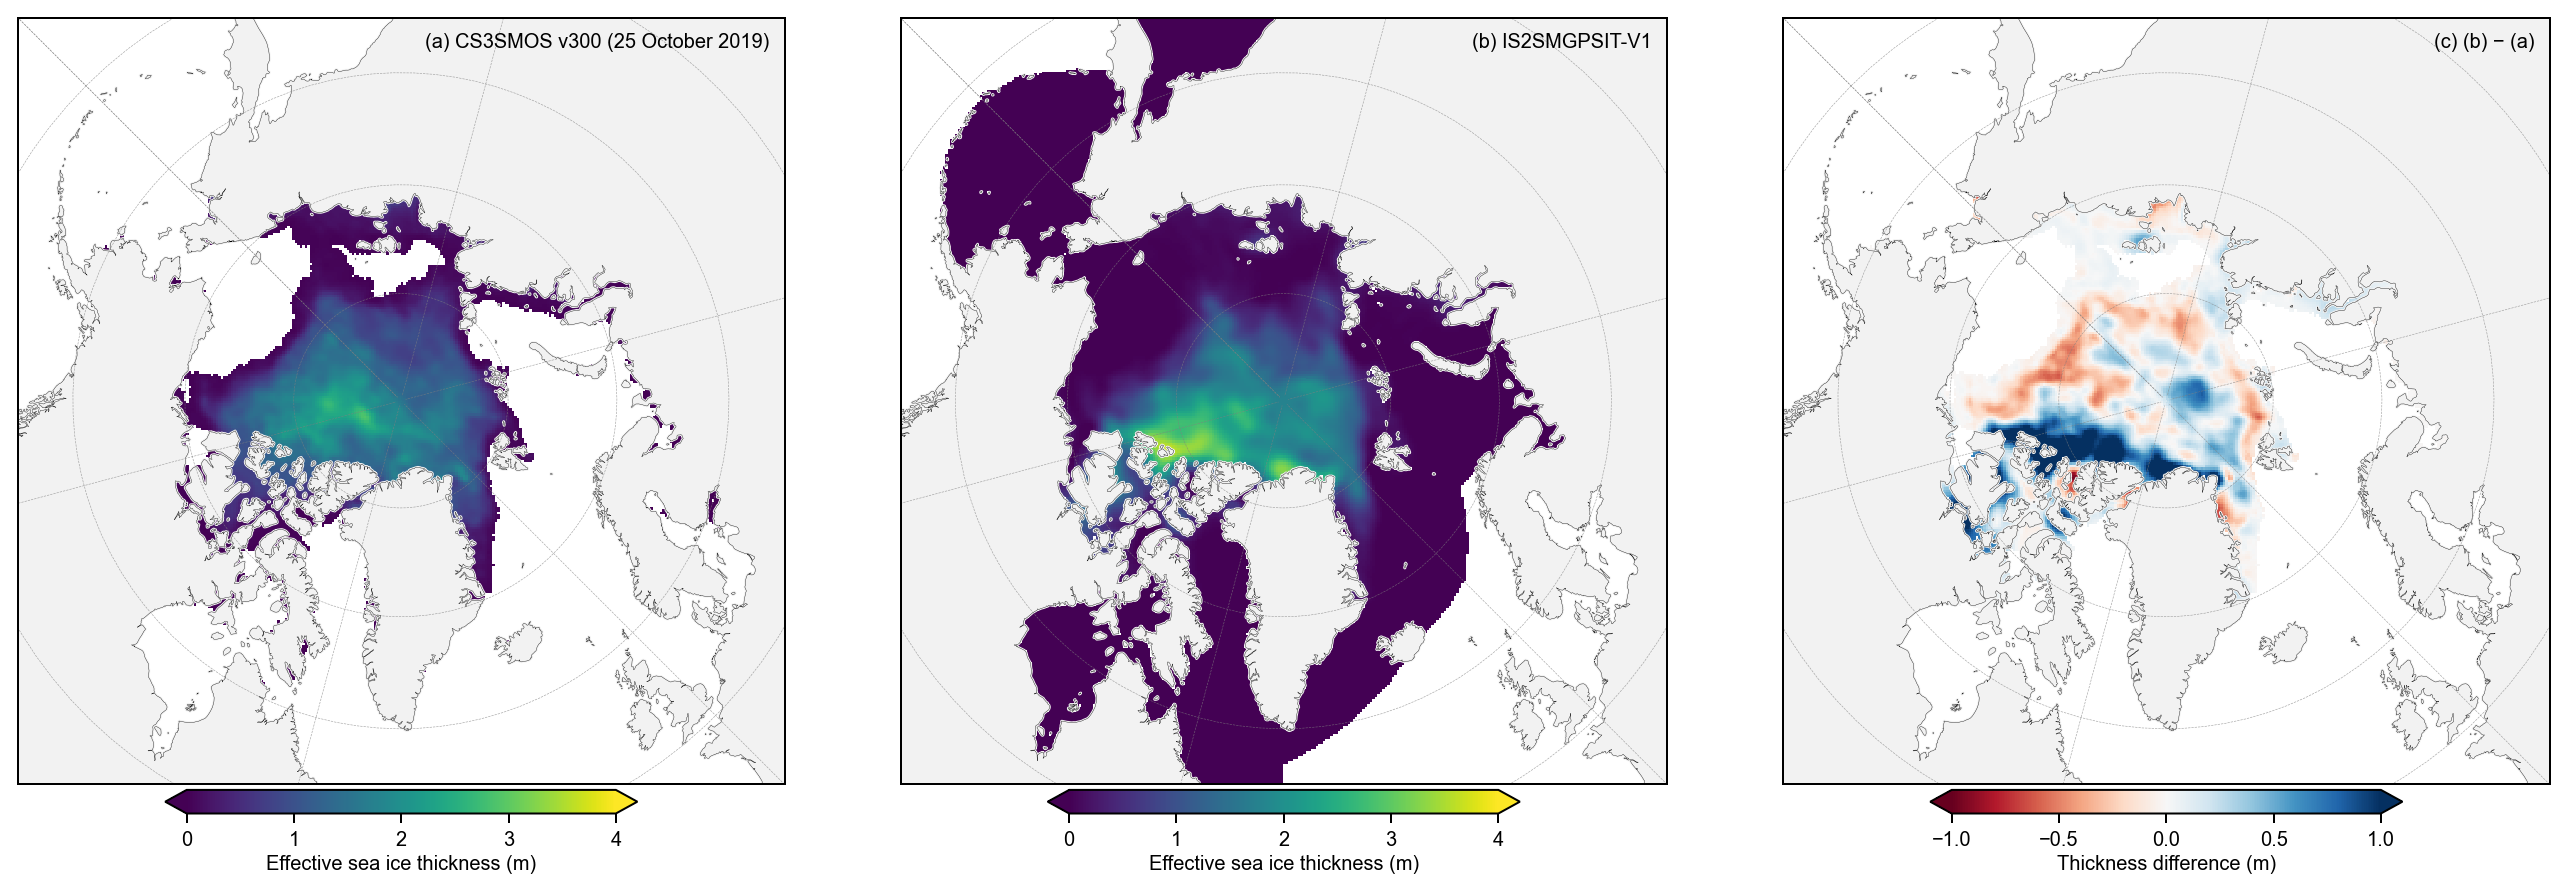

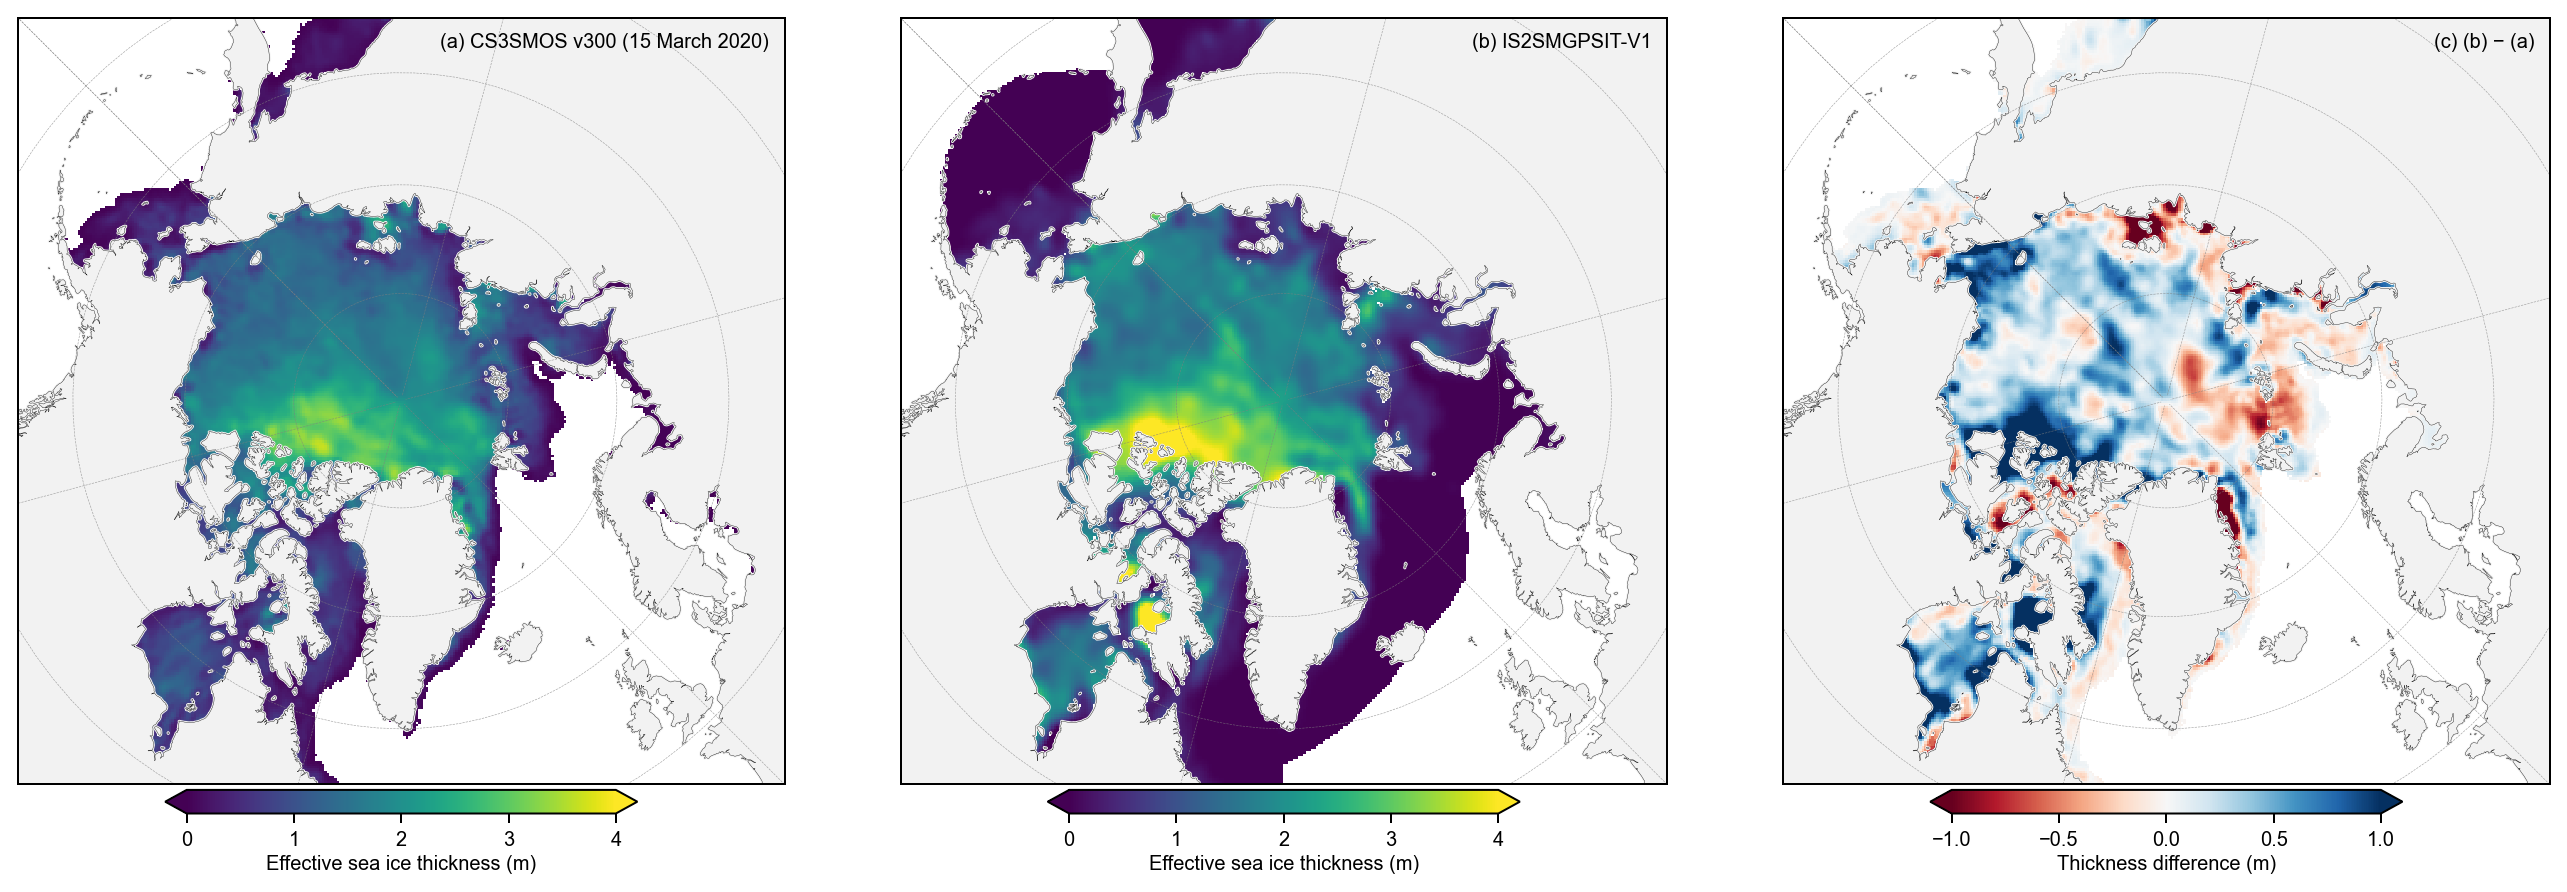

In [8]:
preferred_plot_dates = pd.DatetimeIndex(['2019-10-25', '2020-03-15'])
plot_dates = preferred_plot_dates[preferred_plot_dates.isin(target_dates)]
if len(plot_dates) == 0:
    plot_dates = target_dates[:min(4, len(target_dates))]
n_plot_times = len(plot_dates)

for target_date in plot_dates:
    cs3_map = cs3_effective_on_v1.sel(time=target_date)
    v1_map = thickness_v1_matched.sel(time=target_date)
    fig, axes = plot_is2_v4_vs_fused_three_panel(
        dataarray1=cs3_map,
        dataarray2=v1_map,
        title1='CS3SMOS v300',
        title2='IS2SMGPSIT-V1',
        vmin_thick=0.0,
        vmax_thick=4.0,
        diff_range=(-1.0, 1.0),
        cbarlabels=[
            'Effective sea ice thickness (m)',
            'Effective sea ice thickness (m)',
            'Thickness difference (m)',
        ],
    )
    date_label = pd.Timestamp(target_date).strftime('%d %B %Y')
    axes[0].texts[-1].set_text(f'(a) CS3SMOS v300 ({date_label})')
    date_string = pd.Timestamp(target_date).strftime('%Y%m%d')
    output_path = FIG_DIR / f'11f_cs3smos_effective_thickness_comparison_{date_string}.png'
    plt.savefig(output_path, dpi=250, bbox_inches='tight')
    plt.show()

## Grid-cell comparison

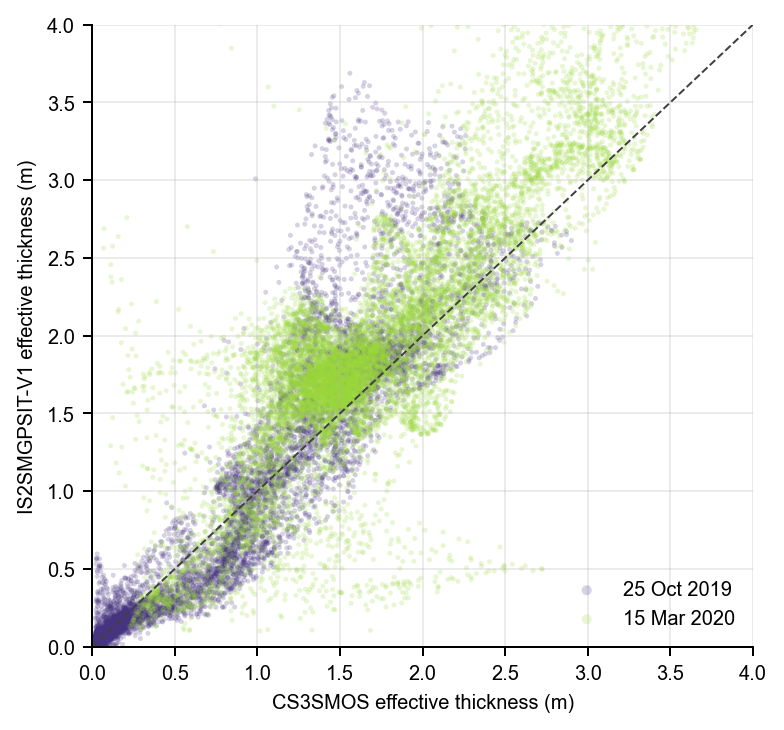

In [9]:
fig, ax = plt.subplots(figsize=(4.4, 4.1))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, n_plot_times))

for color, target_date in zip(colors, plot_dates):
    valid = common_iao.sel(time=target_date).values
    ax.scatter(
        cs3_effective_on_v1.sel(time=target_date).values[valid],
        thickness_v1_matched.sel(time=target_date).values[valid],
        s=4, alpha=0.22, color=color, edgecolors='none',
        label=pd.Timestamp(target_date).strftime('%d %b %Y'),
    )

ax.plot([0, 4], [0, 4], color='0.25', linestyle='--', linewidth=0.8)
ax.set(xlim=(0, 4), ylim=(0, 4), xlabel='CS3SMOS effective thickness (m)', ylabel='IS2SMGPSIT-V1 effective thickness (m)')
ax.grid(alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, markerscale=2)
plt.tight_layout()
plt.savefig(FIG_DIR / '11f_cs3smos_matched_scatter.png', dpi=250, bbox_inches='tight')
plt.show()

## Monthly aggregation of complete paired target-date sets

A monthly result is generated only for periods marked complete above. October and April represent the available CS3SMOS target-date portions of those months, not complete calendar months. Both products are averaged over exactly the same target dates.

In [10]:
complete_periods = pd.PeriodIndex(coverage.index[coverage['complete']], freq='M')
target_periods = target_dates.to_period('M')
complete_times = target_dates[target_periods.isin(complete_periods)]

if len(complete_times) == 0:
    print('No complete months are currently available. Download the remaining target-date files before interpreting monthly means.')
else:
    monthly_cs3 = cs3_effective_on_v1.sel(time=complete_times.values).resample(time='1ME').mean()
    monthly_v1 = thickness_v1_matched.sel(time=complete_times.values).resample(time='1ME').mean()
    monthly_volume_cs3_iao = volume_cs3_iao.sel(time=complete_times.values).resample(time='1ME').mean()
    monthly_volume_v1_iao = volume_v1_matched_iao.sel(time=complete_times.values).resample(time='1ME').mean()
    print('Complete paired monthly periods:', [str(period) for period in complete_periods])
    display(pd.DataFrame({
        'V1 IAO volume (km3)': monthly_volume_v1_iao.values,
        'CS3SMOS IAO volume (km3)': monthly_volume_cs3_iao.values,
    }, index=pd.DatetimeIndex(monthly_volume_cs3_iao.time.values).to_period('M')).round(0))

No complete months are currently available. Download the remaining target-date files before interpreting monthly means.


## Interpretation safeguards

- The mapped comparison is between effective grid-cell thicknesses. Native CS3SMOS `sea_ice_thickness` is not compared directly with V1 because it represents thickness over the ice-covered fraction.
- CS3SMOS target dates are overlapping 7-day analyses, not independent daily retrievals. Monthly averaging reduces plotting noise but does not create independent daily information.
- The quality table should be inspected alongside every comparison, particularly the fraction of cells supplied by interpolation.
- Volume differences can still reflect the products' different concentration inputs, land/ocean masks, and regional boundary mapping.
- The two files initially downloaded are diagnostic samples only. They are insufficient for monthly conclusions.